# Fraud Detection

### What is Fraud Detection?
Fraud detection is the process of monitoring behavior or transactions to identify patterns that deviate from the norm, indicating a high probability of illegal or unauthorized activity.

For financial institutions and e-commerce companies, undetected fraud leads to massive revenue loss, decreased consumer trust, and increased operational costs. Conversely, a system that is too sensitive can lead to "false positives," where legitimate customers' cards are declined, causing frustration and lost sales.


### Dataset
We are going to use [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection/overview).

The data is broken into two files identity and transaction, which are joined by TransactionID. Not all transactions have corresponding identity information.
Categorical Features - Transaction.

#### Categorical Features - Transaction
* ProductCD
* card1 - card6
* addr1, addr2
* P_emaildomain
* R_emaildomain
* M1 - M9

#### Categorical Features - Identity
* DeviceType
* DeviceInfo
* id_12 - id_38

The TransactionDT feature is a timedelta from a given reference datetime (not an actual timestamp).

### Main Goal of the Project
Main Goal of the Project
The primary objective is to build a high-performance binary classification model that predicts whether a new online transaction is fraudulent (1) or legitimate (0).

Beyond simple accuracy, the project focuses on:

**Handling Class Imbalance:** In this dataset, only a very small percentage of transactions are fraudulent. You must ensure the model doesn't simply "guess" that every transaction is legitimate.

**Feature Engineering:** This dataset contains complex, masked features (like V columns and D columns). A key goal is to derive meaningful relationships between user identity, transaction time, and payment methods.

**Minimizing False Positives:** Ensuring that the "User Experience" isn't ruined by blocking valid purchases while still catching the "bad actors."

## 1. Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    average_precision_score,
    accuracy_score
)

## 2. Load Datasets

In [3]:
# Load csv data file.
df_trans = pd.read_csv("./data/train_transaction.csv")
df_id = pd.read_csv("./data/train_identity.csv")

# Left join: keep all transactions, attach identity where available
df = df_trans.merge(df_id, on='TransactionID', how='left')

print("Transaction table shape:", df_trans.shape)
print("Identity table shape:   ", df_id.shape)
print("Merged table shape:     ", df.shape)


Transaction table shape: (590540, 394)
Identity table shape:    (144233, 41)
Merged table shape:      (590540, 434)


## 3 Basic EDA 

In [4]:
#Showing data frame head.
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
# Showing all the column.
df.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [7]:
# Basic statistics for numeric columns
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [8]:
# Fraud label distribution
print("--- Fraud Label Counts ---")
print(df['isFraud'].value_counts())
print()
print("--- As Percentage ---")
print(df['isFraud'].value_counts(normalize=True) * 100)

--- Fraud Label Counts ---
isFraud
0    569877
1     20663
Name: count, dtype: int64

--- As Percentage ---
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


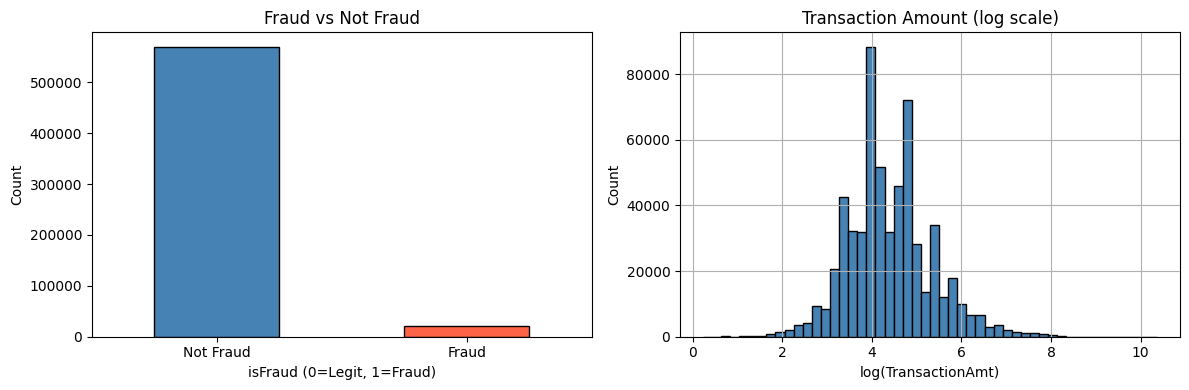

In [9]:
# Plot fraud distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['isFraud'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Fraud vs Not Fraud')
axes[0].set_xlabel('isFraud (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)

# Transaction amount distribution (log scale)
df['TransactionAmt'].apply(np.log1p).hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Transaction Amount (log scale)')
axes[1].set_xlabel('log(TransactionAmt)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4 Missing Value Analysis

In [10]:
# Calculate % missing for every column
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

print(f"{len(missing)} columns have missing values out of {df.shape[1]} total")
print()
print("Top 20 columns with most missing:")
missing.head(20)

414 columns have missing values out of 434 total

Top 20 columns with most missing:


id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_23    99.124699
id_22    99.124699
id_27    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290
dtype: float64

In [11]:
# Group missing into severity buckets
def missing_bucket(pct):
    if pct > 90:   return '>90% — consider dropping'
    elif pct > 50: return '50–90% — handle carefully'
    elif pct > 20: return '20–50% — fill with strategy'
    else:          return '<20%  — easy to fill'

summary = missing.reset_index()
summary.columns = ['column', 'missing']
summary['severity'] = summary['missing'].apply(missing_bucket)

print("--- Missing Value Severity Buckets ---")
print(summary['severity'].value_counts())

--- Missing Value Severity Buckets ---
severity
50–90% — handle carefully      202
<20%  — easy to fill           162
20–50% — fill with strategy     38
>90% — consider dropping        12
Name: count, dtype: int64


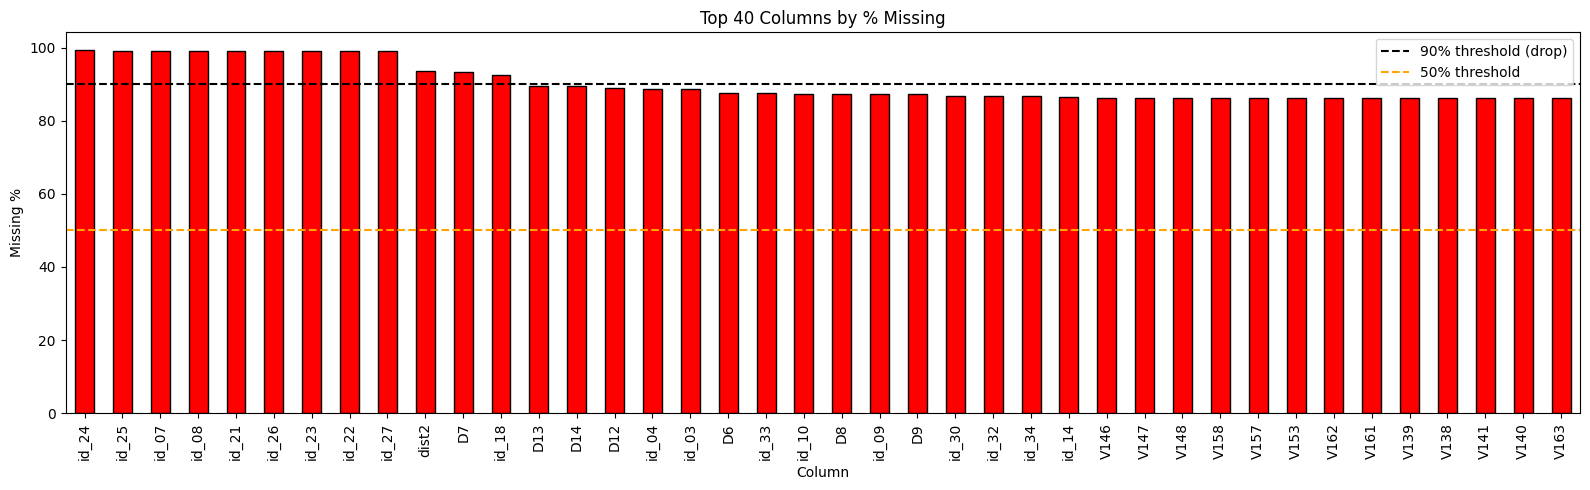

In [12]:
# Visualize top 40 most-missing columns
plt.figure(figsize=(16, 5))
missing.head(40).plot(kind='bar', color='red', edgecolor='black')
plt.title('Top 40 Columns by % Missing')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.axhline(90, color='black', linestyle='--', linewidth=1.5, label='90% threshold (drop)')
plt.axhline(50, color='orange', linestyle='--', linewidth=1.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### 4a. Separate Columns Into Groups

Columns are grouped by their **name prefix** because they share the same meaning and need the same missing value treatment:

| Group | Prefix | What they are |
|---|---|---|
| `v_cols` | `V` | Vesta's anonymized engineered features (V1–V339) |
| `id_cols` | `id_` | Identity features (id_01–id_38) |
| `c_cols` | `C` | Count features (C1–C14) |
| `d_cols` | `D` | Time-delta features (D1–D15) |
| `m_cols` | `M` | Match flag features (M1–M9) |

In [13]:
# Separate into groups
v_cols  = [c for c in df.columns if c.startswith('V')]
id_cols = [c for c in df.columns if c.startswith('id_')]
c_cols  = [c for c in df.columns if c.startswith('C')]
d_cols  = [c for c in df.columns if c.startswith('D')]
m_cols  = [c for c in df.columns if c.startswith('M')]

print("--- Column Group Sizes ---")
print(f"V  columns (Vesta features):     {len(v_cols)}")
print(f"id columns (identity features):  {len(id_cols)}")
print(f"C  columns (count features):     {len(c_cols)}")
print(f"D  columns (timedelta features): {len(d_cols)}")
print(f"M  columns (match flags):        {len(m_cols)}")

print()
print("--- Average % Missing per Group ---")
print(f"V  cols: {df[v_cols].isnull().mean().mean()*100:.1f}%")
print(f"id cols: {df[id_cols].isnull().mean().mean()*100:.1f}%")
print(f"C  cols: {df[c_cols].isnull().mean().mean()*100:.1f}%")
print(f"D  cols: {df[d_cols].isnull().mean().mean()*100:.1f}%")
print(f"M  cols: {df[m_cols].isnull().mean().mean()*100:.1f}%")

--- Column Group Sizes ---
V  columns (Vesta features):     339
id columns (identity features):  38
C  columns (count features):     14
D  columns (timedelta features): 17
M  columns (match flags):        9

--- Average % Missing per Group ---
V  cols: 43.0%
id cols: 84.8%
C  cols: 0.0%
D  cols: 60.5%
M  cols: 49.9%


### 4b. Should We Drop High-Missing ID Columns?

Even with 99% missing, a `id_*` column can still be useful; the 1% that IS present might be almost entirely fraud. Check first before dropping.

In [14]:
# Check how each id column relates to fraud
overall_fraud_rate = df['isFraud'].mean() * 100

results = []
for col in id_cols:
    missing_rate        = df[col].isnull().mean() * 100
    fraud_when_present  = df[df[col].notna()]['isFraud'].mean() * 100
    results.append({
        'column'               : col,
        'missing_%'            : round(missing_rate, 1),
        'fraud_%_when_present' : round(fraud_when_present, 1),
        'overall_fraud_%'      : round(overall_fraud_rate, 1),
        'difference'           : round(fraud_when_present - overall_fraud_rate, 1)
    })

results_df = pd.DataFrame(results).sort_values('difference', ascending=False)
print(f"Overall fraud rate: {overall_fraud_rate:.1f}%")
print()
results_df

Overall fraud rate: 3.5%



,column,missing_%,fraud_%_when_present,overall_fraud_%,difference
3,id_04,88.8,10.7,3.5,7.2
2,id_03,88.8,10.7,3.5,7.2
8,id_09,87.3,10.4,3.5,6.9
9,id_10,87.3,10.4,3.5,6.9
23,id_24,99.2,8.5,3.5,5.0
7,id_08,99.1,8.3,3.5,4.8
12,id_13,78.4,8.3,3.5,4.8
17,id_18,92.4,8.3,3.5,4.8
20,id_21,99.1,8.3,3.5,4.8
6,id_07,99.1,8.3,3.5,4.8


In [15]:
# Decide which id columns to keep vs drop based on fraud signal
useful_id_cols = [
    col for col in id_cols
    if abs(df[df[col].notna()]['isFraud'].mean() - df['isFraud'].mean()) > 0.02
]
weak_id_cols = [c for c in id_cols if c not in useful_id_cols]

print(f" Useful id columns to KEEP: {len(useful_id_cols)}")
print(useful_id_cols)
print()
print(f" Weak id columns to DROP:  {len(weak_id_cols)}")
print(weak_id_cols)

# Drop weak id columns
df = df.drop(columns=weak_id_cols)
print(f"\nShape after smart id dropping: {df.shape}")

 Useful id columns to KEEP: 33
['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38']

 Weak id columns to DROP:  5
['id_14', 'id_30', 'id_32', 'id_33', 'id_34']

Shape after smart id dropping: (590540, 429)


## 5 Drop Remaining Useless Columns

In [16]:
# Drop non-id columns that are >90% missing (already computed in Section 3)
# Exclude id_cols — those were handled smarter in Section 4b
cols_to_drop = [
    c for c in missing[missing > 90].index.tolist()
    if c in df.columns and not c.startswith('id_')
]
print(f"Dropping {len(cols_to_drop)} non-id columns with >90% missing:")
print(cols_to_drop)
df = df.drop(columns=cols_to_drop)

# Drop columns with only 1 unique value — zero information
single_value_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"\nDropping {len(single_value_cols)} single-value columns:")
print(single_value_cols)
df = df.drop(columns=single_value_cols)

print(f"\nShape after dropping useless columns: {df.shape}")

# Refresh column groups once after all dropping is done
v_cols  = [c for c in df.columns if c.startswith('V')]
id_cols = [c for c in df.columns if c.startswith('id_')]
c_cols  = [c for c in df.columns if c.startswith('C')]
d_cols  = [c for c in df.columns if c.startswith('D')]
m_cols  = [c for c in df.columns if c.startswith('M')]
print("\nColumn groups refreshed.")

Dropping 2 non-id columns with >90% missing:
['dist2', 'D7']

Dropping 0 single-value columns:
[]

Shape after dropping useless columns: (590540, 427)

Column groups refreshed.


## 6 Fill Missing Values

| Group | Strategy | Reason |
|---|---|---|
| `id_*` | `-999` sentinel + `has_identity` flag | Missing = no identity record, not random |
| `V*` | Median + null count feature | Anonymized, grouped missingness |
| `C*` | Fill `0` | Missing count = zero activity |
| `D*` | Median | Time-delta gaps |
| `M*` | `'unknown'` | Categorical match flags |
| Core cols | Median or `'unknown'` | Occasional gaps |

In [17]:
# --- 6a. Identity columns ---
# has_identity flag: 1 = identity record exists, 0 = no record
# This single flag is often one of the strongest fraud signals
df['has_identity'] = df['id_01'].notna().astype(int) if 'id_01' in df.columns else 0
print(f"Transactions WITH identity:    {df['has_identity'].sum()}")
print(f"Transactions WITHOUT identity: {(df['has_identity']==0).sum()}")

for col in id_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')
    else:
        df[col] = df[col].fillna(-999)

for col in ['DeviceType', 'DeviceInfo']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

print("\n Identity columns filled")

Transactions WITH identity:    144233
Transactions WITHOUT identity: 446307


C:\Users\Mas85\AppData\Local\Temp\ipykernel_31148\1208882984.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_identity'] = df['id_01'].notna().astype(int) if 'id_01' in df.columns else 0



 Identity columns filled


In [18]:
# --- 6b. V columns ---
# V_null_count = how many V features are missing for this row (useful feature!)
df['V_null_count'] = df[v_cols].isnull().sum(axis=1)

for col in v_cols:
    df[col] = df[col].fillna(df[col].median())

print("V columns filled + V_null_count feature added")

C:\Users\Mas85\AppData\Local\Temp\ipykernel_31148\3461303905.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['V_null_count'] = df[v_cols].isnull().sum(axis=1)


V columns filled + V_null_count feature added


In [19]:
# --- 6c. C, D, M columns ---
# pd.api.types.is_numeric_dtype() catches ALL numeric types
# and avoids the median-on-string error regardless of pandas version

for col in c_cols:
    if col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna('unknown')

for col in d_cols:
    if col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna('unknown')

for col in m_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

print("C, D, M columns filled")
print(f"   C cols: {len(c_cols)}  |  D cols: {len(d_cols)}  |  M cols: {len(m_cols)}")

C, D, M columns filled
   C cols: 14  |  D cols: 16  |  M cols: 9


In [20]:
# --- 6d. Core transaction columns ---
cat_cols = ['card4', 'card6', 'P_emaildomain', 'R_emaildomain']
num_cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if 'TransactionAmt' in df.columns:
    df['TransactionAmt'] = df['TransactionAmt'].fillna(df['TransactionAmt'].median())

print("Core transaction columns filled")

Core transaction columns filled


## 7. Verify — No Missing Values Left

In [21]:
still_missing = df.isnull().mean() * 100
still_missing = still_missing[still_missing > 0]

if len(still_missing) == 0:
    print("No missing values remaining! Your data is clean.")
else:
    print(f" {len(still_missing)} columns still have missing values:")
    print(still_missing)

print(f"\nFinal dataframe shape: {df.shape}")

No missing values remaining! Your data is clean.

Final dataframe shape: (590540, 429)


## 8. Save Clean Data

In [22]:
df.to_csv('./data/train_clean.csv', index=False)
print("Saved to train_clean.csv")

Saved to train_clean.csv


In [3]:
df = pd.read_csv('./data/train_clean.csv')
print("Reloaded train_clean.csv to confirm it was saved correctly.")

Reloaded train_clean.csv to confirm it was saved correctly.


## 9. Encode Categorical Columns

In [4]:
# select_dtypes picks only text columns (object or string dtype)
cat_cols_remaining = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Text columns that need encoding: {len(cat_cols_remaining)}")
print()
for col in cat_cols_remaining:
    print(f"  {col:20} | unique values: {df[col].nunique()}")

Text columns that need encoding: 28

  ProductCD            | unique values: 5
  card4                | unique values: 5
  card6                | unique values: 5
  P_emaildomain        | unique values: 60
  R_emaildomain        | unique values: 61
  M1                   | unique values: 3
  M2                   | unique values: 3
  M3                   | unique values: 3
  M4                   | unique values: 4
  M5                   | unique values: 3
  M6                   | unique values: 3
  M7                   | unique values: 3
  M8                   | unique values: 3
  M9                   | unique values: 3
  id_12                | unique values: 3
  id_15                | unique values: 4
  id_16                | unique values: 3
  id_23                | unique values: 4
  id_27                | unique values: 3
  id_28                | unique values: 3
  id_29                | unique values: 3
  id_31                | unique values: 131
  id_35                | unique val

In [5]:
# LabelEncoder is a tool that assigns a number to each unique text value
le = LabelEncoder()

for col in cat_cols_remaining:
    # astype(str) makes sure even NaN leftovers become the string "nan"
    df[col] = le.fit_transform(df[col].astype(str))

print("All text columns encoded")

All text columns encoded


In [6]:
# After encoding, there should be ZERO text columns left
remaining = df.select_dtypes(include=['object', 'string']).columns.tolist()

if len(remaining) == 0:
    print("No text columns remaining — ready for modeling!")
else:
    print(f"These columns are still text: {remaining}")

# Peek at the result
df[cat_cols_remaining].head()

No text columns remaining — ready for modeling!


,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_27,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,4,1,1,48,49,1,1,1,2,0,...,0,0,0,0,0,0,0,0,2,1774
1,4,2,1,16,49,2,2,2,0,1,...,0,0,0,0,0,0,0,0,2,1774
2,4,4,2,35,49,1,1,1,0,0,...,0,0,0,0,0,0,0,0,2,1774
3,4,2,2,54,49,2,2,2,0,1,...,0,0,0,0,0,0,0,0,2,1774
4,1,2,1,16,49,2,2,2,3,2,...,0,2,2,124,2,1,2,2,1,954


## 10.  Split Data

In [7]:
# Drop TransactionID (just an ID, not useful) and isFraud (that's our target)
X = df.drop(columns=['TransactionID', 'isFraud'])
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to test set
    random_state=42,      # makes the split reproducible (same result every run)
    stratify=y            # keeps fraud ratio same in both train and test
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  472432 rows
Test set:      118108 rows


In [27]:
# Both should show ~3.5% fraud — if stratify worked correctly
print("Fraud ratio check:")
print(f"  Full data:     {y.mean()*100:.1f}%")
print(f"  Training set:  {y_train.mean()*100:.1f}%")
print(f"  Test set:      {y_test.mean()*100:.1f}%")

Fraud ratio check:
  Full data:     3.5%
  Training set:  3.5%
  Test set:      3.5%


## 11. Train LightGBM Model

In [8]:
# Install as iLightGBM was built by Microsoft specifically and it is not a sklearn model. 
# !pip install lightgbm

In [9]:
import lightgbm as lgb
print("LightGBM version:", lgb.__version__)

LightGBM version: 3.3.5


In [10]:
# Define the model
model = lgb.LGBMClassifier(
    n_estimators=500,       # number of trees to build
    learning_rate=0.05,     # how much each tree contributes (smaller = more careful)
    max_depth=6,            # how deep each tree can go
    num_leaves=31,          # complexity of each tree
    is_unbalance=True,      # tells model that fraud is rare — very important!
    random_state=42,        # reproducibility
    n_jobs=-1               # use all CPU cores to speed up training
)


# Train the model

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # watches test performance during training
    callbacks=[lgb.log_evaluation(50)]  # prints progress every 50 trees
)

[50]	valid_0's binary_logloss: 0.344475
[100]	valid_0's binary_logloss: 0.353684
[150]	valid_0's binary_logloss: 0.336413
[200]	valid_0's binary_logloss: 0.322129
[250]	valid_0's binary_logloss: 0.309676
[300]	valid_0's binary_logloss: 0.298881
[350]	valid_0's binary_logloss: 0.289788
[400]	valid_0's binary_logloss: 0.282139
[450]	valid_0's binary_logloss: 0.275221
[500]	valid_0's binary_logloss: 0.268664


LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=6,
               n_estimators=500, random_state=42)

#### Get Important Feature

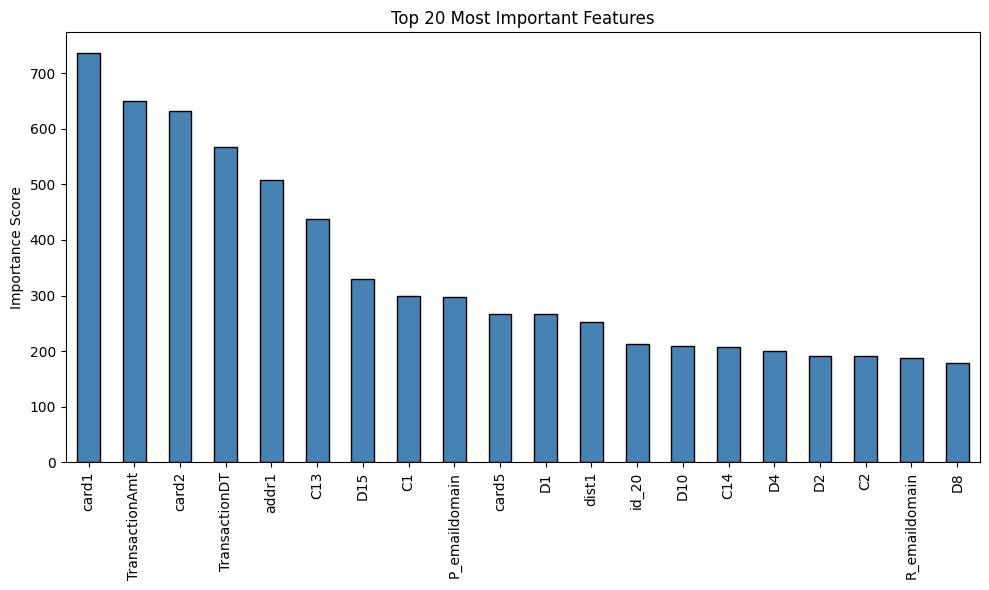


Top 10 features:
card1             737
TransactionAmt    650
card2             633
TransactionDT     568
addr1             508
C13               437
D15               329
C1                300
P_emaildomain     298
card5             267
dtype: int32


In [11]:
# Get feature importances
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 6))
importance.head(20).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Most Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance.head(10))

## 12. Evaluate the Model
#### Accuracy is USELESS here.
If the model predicts "not fraud" for every single transaction: 
**Accuracy = 96.5% ← looks great but the model is completely useless!**

**Because fraud is so rare, accuracy is misleading. Instead your proposal specifically mentions these 3 metrics:**

* **Precision  →** Of all transactions flagged as fraud, how many actually were?
* **Recall     →** Of all actual frauds, how many did we catch?
* **PR-AUC     →** Overall balance between precision and recall (best single number)


### 12.1 Make Prediction

In [32]:
# predict()      → gives 0 or 1 (not fraud / fraud)
# predict_proba()→ gives a probability score between 0 and 1
#                  e.g. 0.92 means "92% confident this is fraud"

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # [:, 1] gets the fraud probability

print("Sample predictions:")
print(y_pred[:10])
print("\nSample fraud probabilities:")
print(y_pred_proba[:10].round(3))

Sample predictions:
[0 0 0 0 0 0 0 0 0 0]

Sample fraud probabilities:
[0.035 0.165 0.101 0.066 0.06  0.181 0.089 0.035 0.056 0.076]


### 12.2 MODEL EVALUATION RESULTS

In [33]:
print("=" * 50)
print("          MODEL EVALUATION RESULTS")
print("=" * 50)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
pr_auc    = average_precision_score(y_test, y_pred_proba)

print(f"Accuracy  : {accuracy:.4f}  ← NOT a reliable metric for fraud detection")
print(f"            (model can score 96% by always predicting 'not fraud')")
print()
print(f"Precision : {precision:.4f}  → of flagged fraud, {precision*100:.1f}% were real")
print(f"Recall    : {recall:.4f}  → caught {recall*100:.1f}% of all actual frauds")
print(f"PR-AUC    : {pr_auc:.4f}  → overall score (higher = better, max 1.0)")
print("=" * 50)
print("* For this project Precision, Recall and PR-AUC")
print("  are the metrics that matter per the proposal.")
print("=" * 50)

print("\nFull breakdown:")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

          MODEL EVALUATION RESULTS
Accuracy  : 0.9096  ← NOT a reliable metric for fraud detection
            (model can score 96% by always predicting 'not fraud')

Precision : 0.2548  → of flagged fraud, 25.5% were real
Recall    : 0.8231  → caught 82.3% of all actual frauds
PR-AUC    : 0.6699  → overall score (higher = better, max 1.0)
* For this project Precision, Recall and PR-AUC
  are the metrics that matter per the proposal.

Full breakdown:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.91      0.95    113975
       Fraud       0.25      0.82      0.39      4133

    accuracy                           0.91    118108
   macro avg       0.62      0.87      0.67    118108
weighted avg       0.97      0.91      0.93    118108



### 12.3 Plot the Precision-Recall curve

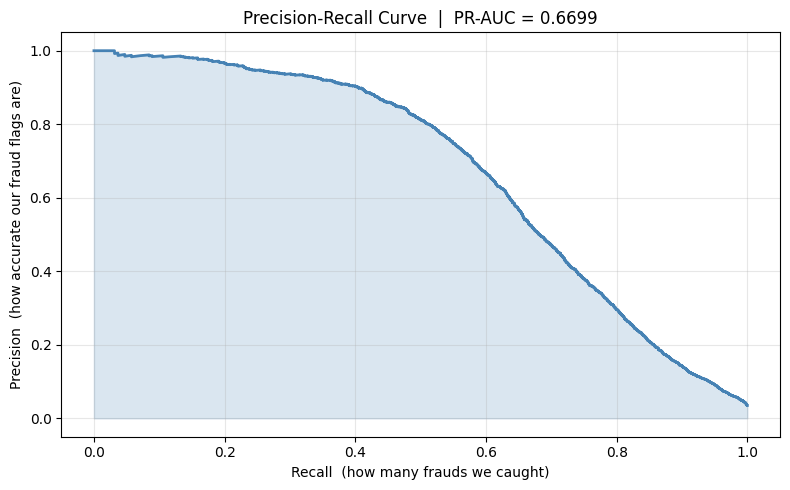

In [34]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color='steelblue', linewidth=2)
plt.fill_between(recall_curve, precision_curve, alpha=0.2, color='steelblue')
plt.xlabel('Recall  (how many frauds we caught)')
plt.ylabel('Precision  (how accurate our fraud flags are)')
plt.title(f'Precision-Recall Curve  |  PR-AUC = {pr_auc:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.4 Confusion matrix

<Figure size 600x500 with 0 Axes>

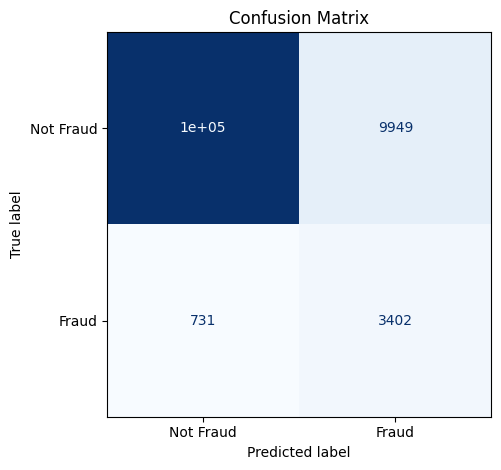


Plain English:
   Correctly caught fraud:       3402
   Correctly cleared legit:      104026
   Missed fraud (dangerous!):    731
   False alarms (annoying):      9949


In [35]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Fraud', 'Fraud'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plain English explanation
tn, fp, fn, tp = cm.ravel()
print(f"\nPlain English:")
print(f"   Correctly caught fraud:       {tp}")
print(f"   Correctly cleared legit:      {tn}")
print(f"   Missed fraud (dangerous!):    {fn}")
print(f"   False alarms (annoying):      {fp}")

## 13. Save the model

In [36]:
import joblib

# joblib is the standard way to save sklearn-style models
# it compresses the model into a single file

joblib.dump(model, 'fraud_model.pkl')

print("✅ Model saved as fraud_model.pkl")

# Check the file size — important for Lambda's 50MB limit
import os
size_mb = os.path.getsize('fraud_model.pkl') / (1024 * 1024)
print(f"   File size: {size_mb:.2f} MB")
print()
if size_mb < 50:
    print("✅ Under 50MB — safe to deploy to AWS Lambda")
else:
    print("⚠️  Over 50MB — need to reduce model size for Lambda")

✅ Model saved as fraud_model.pkl
   File size: 1.68 MB

✅ Under 50MB — safe to deploy to AWS Lambda


### 13.1 Verifying model

In [ ]:
# Always verify the saved model works before deploying
loaded_model = joblib.load('fraud_model.pkl', compress=0)

# Make a test prediction with the loaded model
test_pred = loaded_model.predict(X_test[:5])
original_pred = model.predict(X_test[:5])

print("Original model predictions: ", original_pred)
print("Loaded model predictions:   ", test_pred)
print()

if (test_pred == original_pred).all():
    print("Loaded model gives identical predictions — safe to deploy!")
else:
    print("Predictions don't match — something went wrong")

Original model predictions:  [0 0 0 0 0]
Loaded model predictions:    [0 0 0 0 0]

Loaded model gives identical predictions — safe to deploy!


## 14. Saving the Column list for Lamda.

In [38]:
# This is very important!
# Lambda needs to know EXACTLY which columns to expect
# and in EXACTLY the same order as training

import json

feature_columns = X_train.columns.tolist()

with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

print(f"✅ Saved {len(feature_columns)} feature column names to feature_columns.json")
print()
print("First 10 columns:")
print(feature_columns[:10])

✅ Saved 427 feature column names to feature_columns.json

First 10 columns:
['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1']


In [14]:
import lightgbm as lgb
import joblib
import json
import os

print(f"Model type: {type(model)}")
print(f"LightGBM version: {lgb.__version__}")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features: {model.n_features_in_}")
print(f"Classes: {model.classes_}")
print(f"X_train columns: {len(X_train.columns)}")
print(f"First 5 features: {list(X_train.columns[:5])}")

Model type: <class 'lightgbm.sklearn.LGBMClassifier'>
LightGBM version: 3.3.5
Number of trees: 500
Number of features: 427
Classes: [0 1]
X_train columns: 427
First 5 features: ['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2']


In [15]:
# Save model -- no compression
joblib.dump(model, "fraud_model.pkl", compress=0)

# Save feature columns
feature_cols = list(X_train.columns)
with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

# Verify sizes
print(f"Model size  : {os.path.getsize('fraud_model.pkl') / 1024 / 1024:.2f} MB")
print(f"Feature file: {os.path.getsize('feature_columns.json')} bytes")
print(f"Feature count: {len(feature_cols)}")

Model size  : 1.68 MB
Feature file: 3357 bytes
Feature count: 427
